# 02 · Robustez: sazonalidade e autocorrelação

Este notebook **não altera** os resultados publicados, que estão reproduzidos em `01_replicacao_mqo.ipynb`. Ele testa a sensibilidade das conclusões a duas questões que a versão do artigo não trata:

1. **Sazonalidade.** As séries não têm ajuste sazonal, e a variável `PIB_China` foi construída como a variação do PIB nominal chinês em relação ao trimestre anterior (`100 × (1 + taxa)`). Como o PIB nominal da China cai fortemente todo primeiro trimestre, a variável pode estar captando o calendário, e não a demanda chinesa.
2. **Autocorrelação.** O artigo aplica uma única quase-diferença, com $\hat\rho$ tirado do Durbin-Watson. Aqui ela é comparada com erros-padrão robustos (Newey-West) e com o procedimento iterativo de Cochrane-Orcutt.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

FIG = "../output/figures/"
TAB = "../output/tables/"

dados = pd.read_csv("../data/exportacoes_trimestral.csv", index_col="serie")
dados.columns = ["quantum", "preco_basico", "cambio", "pib_china"]
dados["trimestre"] = (dados.index % 10).astype(str)

## 1. O padrão sazonal

In [2]:
medias = dados.groupby("trimestre")[["quantum", "pib_china"]].mean()
display(medias.round(1))

q1 = (dados["trimestre"] == "1").astype(int)
print(f"Correlação entre PIB_China e o indicador de 1º trimestre: {np.corrcoef(dados['pib_china'], q1)[0, 1]:.2f}")

,quantum,pib_china
trimestre,,
1,262.9,84.7
2,309.9,112.3
3,321.8,106.0
4,301.2,111.2


Correlação entre PIB_China e o indicador de 1º trimestre: -0.96


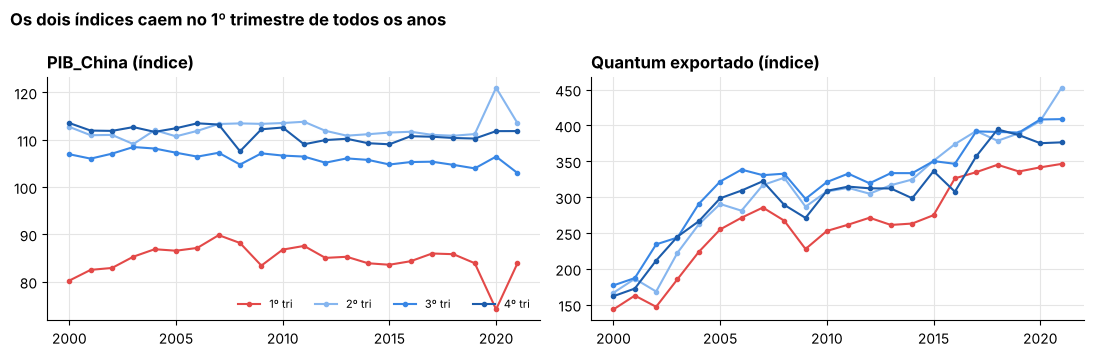

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, titulo in [(axes[0], "pib_china", "PIB_China (índice)"), (axes[1], "quantum", "Quantum exportado (índice)")]:
    for tri, cor in zip("1234", ["#e34948", "#86b6ef", "#3987e5", "#1c5cab"]):
        s = dados[dados["trimestre"] == tri][col]
        ax.plot(s.index // 10, s.values, "o-", color=cor, markersize=3, linewidth=1.5, label=f"{tri}º tri")
    ax.set_title(titulo, loc="left", fontweight="bold")
    ax.grid(color="#e5e5e5"); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, ncol=4, loc="lower right", fontsize=8)
fig.suptitle("Os dois índices caem no 1º trimestre de todos os anos", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG + "sazonalidade.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Especificações alternativas

In [4]:
base = "quantum ~ preco_basico + cambio + pib_china"
nw = dict(cov_type="HAC", cov_kwds={"maxlags": 4})

especificacoes = {
    "(1) MQO em nível — artigo": smf.ols(base, dados).fit(),
    "(2) MQO + erros Newey-West": smf.ols(base, dados).fit(**nw),
    "(3) MQO + dummies trimestrais": smf.ols(base + " + C(trimestre)", dados).fit(),
    "(4) MQO + dummies + Newey-West": smf.ols(base + " + C(trimestre)", dados).fit(**nw),
}

y = dados["quantum"]
X = sm.add_constant(dados[["preco_basico", "cambio", "pib_china"]])
Xd = X.join(pd.get_dummies(dados["trimestre"], prefix="tri", drop_first=True).astype(float))
especificacoes["(5) Cochrane-Orcutt iterativo"] = sm.GLSAR(y, X, rho=1).iterative_fit(maxiter=50)
especificacoes["(6) Cochrane-Orcutt iterativo + dummies"] = sm.GLSAR(y, Xd, rho=1).iterative_fit(maxiter=50)

linhas = []
for nome, m in especificacoes.items():
    for v in ["preco_basico", "cambio", "pib_china"]:
        linhas.append({"especificacao": nome, "variavel": v, "coef": m.params[v],
                       "erro_padrao": m.bse[v], "p_valor": m.pvalues[v]})
robustez = pd.DataFrame(linhas)
robustez.round(4).to_csv(TAB + "robustez.csv", index=False)

robustez.pivot(index="especificacao", columns="variavel", values=["coef", "p_valor"]).round(3)

coef                        p_valor  \
variavel                                cambio pib_china preco_basico  cambio   
especificacao                                                                   
(1) MQO em nível — artigo                0.269     1.479        0.532   0.000   
(2) MQO + erros Newey-West               0.269     1.479        0.532   0.010   
(3) MQO + dummies trimestrais            0.273     2.089        0.534   0.000   
(4) MQO + dummies + Newey-West           0.273     2.089        0.534   0.007   
(5) Cochrane-Orcutt iterativo            0.058     1.207        0.330   0.537   
(6) Cochrane-Orcutt iterativo + dummies  0.043     1.603        0.186   0.567   

                                                                
variavel                                pib_china preco_basico  
especificacao                                                   
(1) MQO em nível — artigo                   0.002        0.000  
(2) MQO + erros Newey-West                  0.000        0.000  
(3) MQO + dummies trimestrais               0.398        0.000  
(4) MQO + dummies + Newey-West              0.376        0.000  
(5) Cochrane-Orcutt iterativo               0.000        0.014  
(6) Cochrane-Orcutt iterativo + dummies     0.027        0.109

## 3. Leitura dos resultados

- **Preço básico** tem efeito positivo e significativo no MQO com ou sem dummies trimestrais. No Cochrane-Orcutt iterativo com dummies, o coeficiente cai e perde significância a 10%.
- **Câmbio efetivo** é significativo nos modelos em nível, mesmo com erros Newey-West. Quando a autocorrelação é modelada (Cochrane-Orcutt), perde significância em todas as versões, o que reforça a conclusão do artigo.
- **PIB da China** é a variável mais sensível. No MQO em nível, as dummies trimestrais absorvem o seu efeito (p ≈ 0,4), porque a variável e o 1º trimestre têm correlação de −0,96. No Cochrane-Orcutt iterativo, o efeito permanece significativo mesmo com as dummies.

**Implicação.** A direção dos resultados se mantém, mas a magnitude atribuída à demanda chinesa depende de como se trata a sazonalidade. Uma especificação mais robusta usaria séries dessazonalizadas, o PIB chinês em nível (ou suas importações) em logaritmo e testes de raiz unitária e cointegração, já que as variáveis em nível têm tendência.